In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import itertools
import numpy as np
import holidays



In [ ]:
# Cargamos el dataset
df = pd.read_csv("C:/Users/alexa/OneDrive/Documentos/Curso5/Proyectos4/casa_60_clima.csv", parse_dates=True)
df = df.drop(columns=['fecha'])

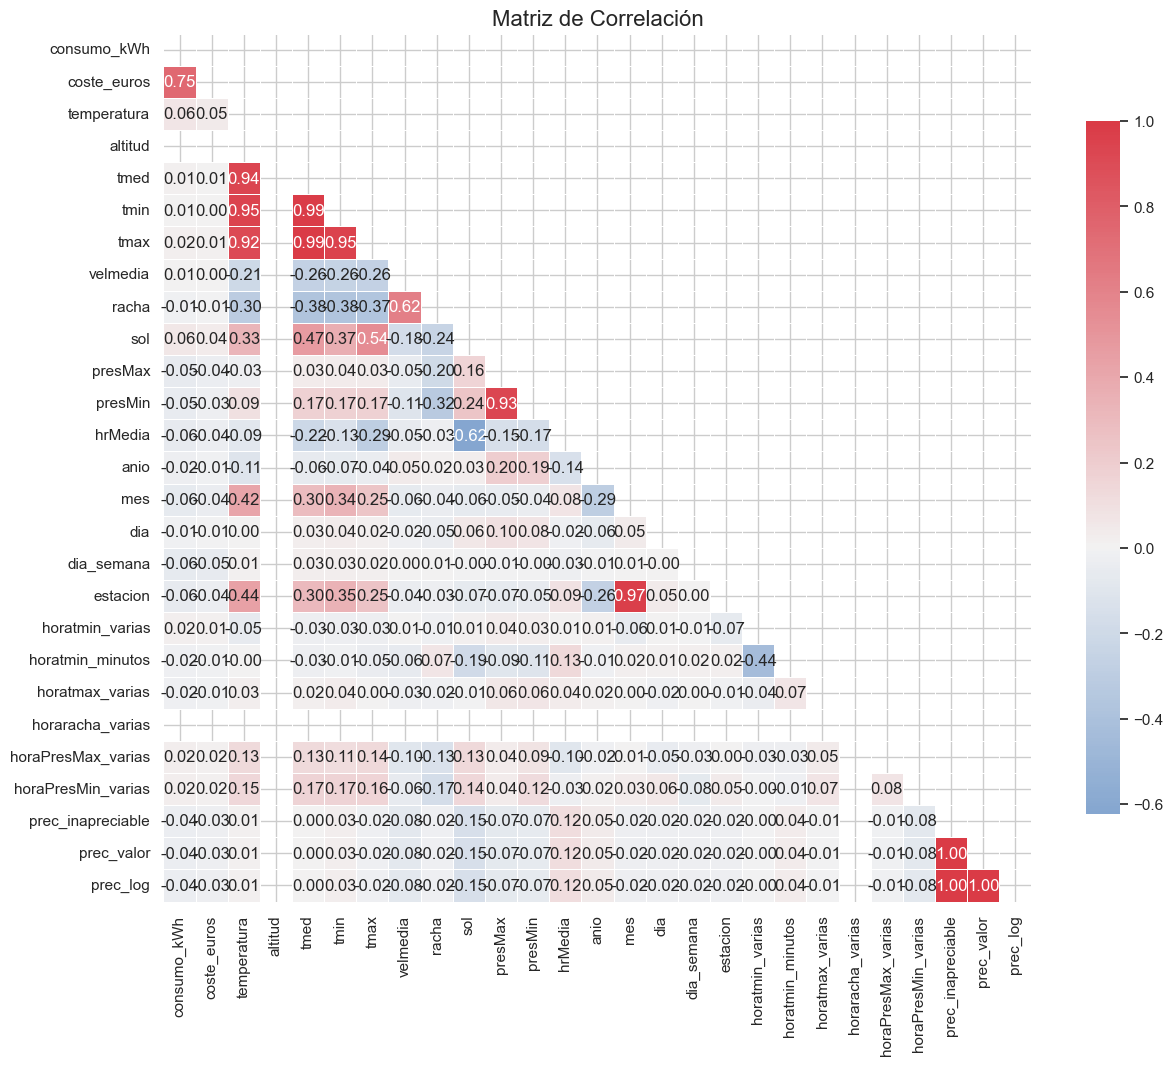

consumo_kWh           1.000000
coste_euros           0.746337
temperatura           0.061655
sol                   0.058590
horaPresMin_varias    0.024618
horaPresMax_varias    0.023612
tmax                  0.021829
horatmin_varias       0.017500
tmed                  0.014482
tmin                  0.005860
velmedia              0.005657
racha                -0.008340
dia                  -0.010698
horatmin_minutos     -0.015156
horatmax_varias      -0.020038
anio                 -0.024830
prec_log             -0.038000
prec_valor           -0.038000
prec_inapreciable    -0.038000
presMin              -0.048728
presMax              -0.054893
estacion             -0.056574
hrMedia              -0.057015
dia_semana           -0.059479
mes                  -0.063855
altitud                    NaN
horaracha_varias           NaN
Name: consumo_kWh, dtype: float64


In [ ]:
sns.set(style="whitegrid")
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(14, 12))
cmap = sns.diverging_palette(250, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, center=0, annot=True, fmt=".2f",
            square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title("Matriz de Correlación", fontsize=16)
plt.show()

print(corr["consumo_kWh"].sort_values(ascending=False))


In [ ]:
# Renombramos target a 'y' y creamos 'ds'
df = df.rename(columns={'timestamp':'ds', 'consumo_kWh':'y'})

# Eliminamos columnas sin información o muy redundantes
df = df.drop(columns=['altitud','tmed','tmin','tmax'])

In [ ]:
# Lags de consumo
for lag in [1, 24, 168]:
    df[f'lag_{lag}'] = df['y'].shift(lag)

# Medias móviles
for window in [3, 6, 24]:
    df[f'rollmean_{window}'] = df['y'].shift(1).rolling(window).mean()

# Tendencia semanal 
df['week_avg'] = df['y'].shift(1).rolling(168).mean()
df['trend_diff'] = df['y'].shift(1) - df['week_avg']

df_model = df.dropna().reset_index(drop=True)



In [ ]:
lag_regs  = [f'lag_{l}'        for l in [1, 24, 168]]
roll_regs = [f'rollmean_{w}'   for w in [3, 6, 24]]
base_regs = lag_regs + roll_regs + ['trend_diff']

meteo_vars = ['temperatura', 'velmedia', 'sol', 'presMax', 'prec_valor']
meteo_regs = base_regs + meteo_vars

regressor_sets = {
    'base':       base_regs,
    'with_meteo': meteo_regs
}

In [34]:
# ==============================
# 4. Holidays centrados en Barcelona (Cataluña)
# ==============================
# Generamos el calendario de festivos de España, provincia CT (Cataluña)
date = pd.to_datetime(df_model['ds'])
years = range(date.dt.year.min(), date.dt.year.max()+1)
spain_ct = holidays.Spain(prov='CT', years=years)
holiday_df = pd.DataFrame([
    {'ds': pd.to_datetime(day), 'holiday': name}
    for day, name in spain_ct.items()
])

In [ ]:
# Hiperparámetros a tunear
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 10.0, 20.0],
    'seasonality_mode':        ['additive','multiplicative']
}
all_params = [dict(zip(param_grid.keys(), vals))
              for vals in itertools.product(*param_grid.values())]

results = []

for set_name, regs in regressor_sets.items():
    best_rmse = np.inf
    best_params = None
    
    for params in all_params:
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=True,
            holidays=holiday_df,
            **params
        )
        for r in regs:
            m.add_regressor(r)
        
        m.fit(df_model[['ds','y'] + regs])
        
        df_cv = cross_validation(
            m,
            initial='365 days',
            period='7 days',
            horizon='1 hours',
            parallel='processes'
        )
        perf = performance_metrics(df_cv)
        rmse_1h = perf[perf.horizon=='1 hours']['rmse'].values[0]
        
        if rmse_1h < best_rmse:
            best_rmse = rmse_1h
            best_params = params
    
    results.append({
        'regressor_set': set_name,
        'best_params': best_params,
        'rmse_1h': best_rmse
    })
for r in results:
    print(f"Set: {r['regressor_set']}, RMSE @1h: {r['rmse_1h']:.4f}, params: {r['best_params']}")

best = min(results, key=lambda x: x['rmse_1h'])
print("\nMejor conjunto:", best['regressor_set'])



11:44:10 - cmdstanpy - INFO - Chain [1] start processing
11:44:26 - cmdstanpy - INFO - Chain [1] done processing
11:44:26 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
11:48:06 - cmdstanpy - INFO - Chain [1] start processing
11:48:06 - cmdstanpy - INFO - Chain [1] start processing
11:48:16 - cmdstanpy - INFO - Chain [1] done processing
11:48:16 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
11:50:41 - cmdstanpy - INFO - Chain [1] start processing
11:50:41 - cmdstanpy - INFO - Chain [1] start processing
11:50:56 - cmdstanpy - INFO - Chain [1] done processing
11:50:56 - cmdstanp

Set: base, RMSE @1h: 2.2433, params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 20.0, 'seasonality_mode': 'additive'}
Set: with_meteo, RMSE @1h: 2.1975, params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}

Mejor conjunto: with_meteo


In [ ]:
final_regs = regressor_sets[best['regressor_set']]
m_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    holidays=holiday_df,
    **best['best_params']
)
for r in final_regs:
    m_final.add_regressor(r)

m_final.fit(df_model[['ds','y'] + final_regs])





18:11:49 - cmdstanpy - INFO - Chain [1] start processing
18:12:33 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
df_model[['ds','y'] + final_regs]

,ds,y,lag_1,lag_24,lag_168,rollmean_3,rollmean_6,rollmean_24,trend_diff,temperatura,velmedia,sol,presMax,prec_valor
0,2017-12-22 12:00:00,73.0,69.0,72.0,66.0,67.000000,55.500000,55.041667,18.089286,12.75,9.4,5.1,983.6,0.00
1,2017-12-22 13:00:00,70.0,73.0,72.0,71.0,70.000000,61.333333,55.083333,15.047619,13.18,9.4,5.1,983.6,0.00
2,2017-12-22 14:00:00,71.0,70.0,75.0,76.0,70.666667,65.500000,55.000000,16.053571,13.50,9.4,5.1,983.6,0.00
3,2017-12-22 15:00:00,75.0,71.0,78.0,78.0,71.333333,69.166667,54.833333,20.083333,13.68,9.4,5.1,983.6,0.00
4,2017-12-22 16:00:00,70.0,75.0,72.0,67.0,72.000000,71.000000,54.708333,15.101190,13.68,9.4,5.1,983.6,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19088,2020-02-25 20:00:00,73.0,67.0,67.0,73.0,52.666667,50.666667,47.958333,31.726190,13.20,4.2,3.6,970.4,0.05
19089,2020-02-25 21:00:00,70.0,73.0,69.0,68.0,62.666667,55.000000,48.208333,28.726190,13.29,4.2,3.6,970.4,0.05
19090,2020-02-25 22:00:00,54.0,70.0,50.0,49.0,70.000000,58.666667,48.250000,12.714286,13.19,4.2,3.6,970.4,0.05
19091,2020-02-25 23:00:00,31.0,54.0,34.0,32.0,65.666667,59.166667,48.416667,-10.315476,13.44,4.2,3.6,970.4,0.05


In [ ]:

last = df_model.iloc[-1]
next_ds = pd.to_datetime(last['ds']) + pd.Timedelta(hours=1)
df_pred = pd.DataFrame({'ds': [next_ds]})

for r in final_regs:
    if r.startswith('lag_'):
        lag = int(r.split('_')[1])
        df_pred[r] = df_model['y'].iloc[-lag]
    elif r.startswith('rollmean_'):
        window = int(r.split('_')[1])
        df_pred[r] = df_model['y'].iloc[-window:].mean()
    elif r == 'trend_diff':
        week_avg = df_model['y'].iloc[-168:].mean()
        last_y   = df_model['y'].iloc[-1]
        df_pred[r] = last_y - week_avg
    else:
        df_pred[r] = last[r]

forecast = m_final.predict(df_pred)


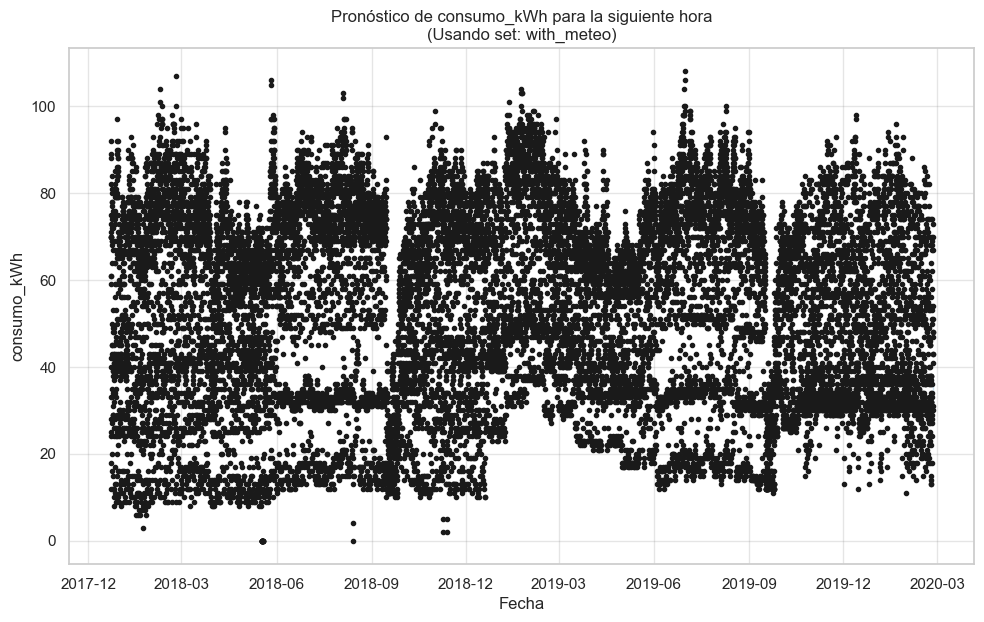

In [ ]:
fig = m_final.plot(forecast)
plt.title(f"Pronóstico de consumo_kWh para la siguiente hora\n(Usando set: {best['regressor_set']})")
plt.xlabel('Fecha')
plt.ylabel('consumo_kWh')
plt.show()